In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI

In [2]:
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_8772b5f549', 'id': 'chatcmpl-Dyxqlxyhzott1FVuVkHNeP4l9dXGK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f3c3d-d229-7202-9f07-62b269cc6bf2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [3]:
# Tools

def add(a: int,b: int) -> int:
    """Adds a and b.
    
    Args:
        a: fist int
        b : second int
    """
    return  a+b

def multiply(a: int,b: int) -> int:
    """Multiply a and b.
    
    Args:
        a: fist int
        b : second int
    """
    return  a*b

def divide(a: int,b: int) -> int:
    """Divide a and b.
    
    Args:
        a: fist int
        b : second int
    """
    return  a/b

tools = [add,multiply,divide]

In [4]:
tools

[<function __main__.add(a: int, b: int) -> int>,
 <function __main__.multiply(a: int, b: int) -> int>,
 <function __main__.divide(a: int, b: int) -> int>]

In [5]:
# Integrate tools with llm
llm_with_tools=llm.bind_tools(tools)

In [6]:
llm_with_tools

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9', 'langchain-openai': '1.3.2'}}, output_version=None, profile={'name': 'GPT-4o', 'release_date': '2024-05-13', 'last_updated': '2024-08-06', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001F21E9752B0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001F21F1C30E0>, root_client=<ope

In [7]:
# Workflow
from langgraph.checkpoint.memory import MemorySaver
from typing_extensions import TypedDict, Literal
from langgraph.graph import MessagesState,StateGraph,START,END
from IPython.display import Image,display
from pydantic import BaseModel,Field
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import HumanMessage,SystemMessage

In [8]:
# Systeme message
sys_msg = SystemMessage(content="You are an helpful assitant tasked with peformed arithmetic on a set of inputs.")

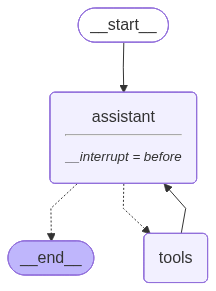

In [9]:
# Nodes definition
def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder=StateGraph(MessagesState)

# Define nodes
builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))

# Define edges
builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools","assistant")

memory=MemorySaver()

graph=builder.compile(interrupt_before=["assistant"],checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
thread={"configurable":{"thread_id":"123"}}

initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

In [11]:
for event in graph.stream(initial_input,thread,stream_mode="values"): # .stream() : pour voir l'éxécution étape par étape par rapoort à invoke qui ne donne que le résultat final
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


Interruption avant l'assistant

Chaque fois qu'il y a une interruption, l'ensemble est sauvegardé dans les points de contrôle

In [12]:
state=graph.get_state(thread)
state.next

('assistant',)

In [13]:
graph.get_state_history(thread)

<generator object Pregel.get_state_history at 0x000001F21F63FE20>

In [14]:
# Continue the execution to assistant
for event in graph.stream(None,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_8UOJIl2wPkRmixTkCPJ6XQwu)
 Call ID: call_8UOJIl2wPkRmixTkCPJ6XQwu
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [15]:
# Continue the execution of assistant and then end
for event in graph.stream(None,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


## Edit Human feedback

In [16]:
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

thread={"configurable":{"thread_id":"1"}}

for event in graph.stream(initial_input,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [17]:
state=graph.get_state(thread)
state.next

('assistant',)

In [18]:
graph.update_state(thread, {"messages":[HumanMessage(content="No, please multiply 15 and 6")]})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f179f34-ef3c-663f-8001-425fec7cdeaf'}}

In [19]:
new_state=graph.get_state(thread).values

for m in new_state["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No, please multiply 15 and 6


In [20]:
for event in graph.stream(None,thread,stream_mode='values'):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

No, please multiply 15 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (call_EtVbEKCSL15Erw2lxl51L6ld)
 Call ID: call_EtVbEKCSL15Erw2lxl51L6ld
  Args:
    a: 15
    b: 6
================================= Tool Message =================================
Name: multiply

90


On remarque l'interruption en tool et assistant

In [21]:
for event in graph.stream(None,thread,stream_mode='values'):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

90
================================== Ai Message ==================================

Sure, the result of multiplying 15 and 6 is 90.


L'interruption est levé dès qu'on relance la requête

## Workflow will wait for the user input

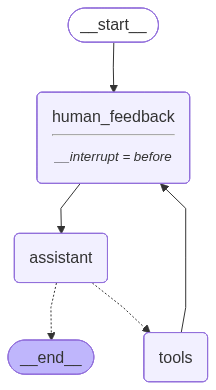

In [22]:
# Systeme message
sys_msg = SystemMessage(content="You are an helpful assitant tasked with peformed arithmetic on a set of inputs.")

# Human feedback node

def Human_feedback(state:MessagesState):
    pass

# Assistant node
def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder=StateGraph(MessagesState)

# Define nodes
builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))
builder.add_node("human_feedback",Human_feedback)

# Define edges
builder.add_edge(START,"human_feedback")
builder.add_edge("human_feedback","assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools","human_feedback")

memory=MemorySaver()

graph=builder.compile(interrupt_before=["human_feedback"],checkpointer=memory)

# Visualize the graph
display(Image(graph.get_graph().draw_mermaid_png()))
    

In [23]:
# Input

initial_input = {"messages": [HumanMessage(content="Multiply 2 and 3")]}

thread = {"configurable" : {"thread_id" : "5"}}

for event in graph.stream(initial_input,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

# Get user input

user_input = input("Tell me how you want to update the state")
graph.update_state(thread,{"messages":user_input},as_node="human_feedback")

for event in graph.stream(None,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

please multiply 5 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (call_zdXTLgeLkohuGAecU8LGakfl)
 Call ID: call_zdXTLgeLkohuGAecU8LGakfl
  Args:
    a: 2
    b: 3
  multiply (call_Z1FPPgrm4aXKujpCXFvsCXIG)
 Call ID: call_Z1FPPgrm4aXKujpCXFvsCXIG
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multiply

30


In [24]:
for event in graph.stream(None,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

30
================================== Ai Message ==================================

The product of 2 and 3 is 6, and the product of 5 and 6 is 30.
